# 🔐 Cybersecurity Log Analysis & Threat Detection

This project analyzes authentication logs to identify suspicious activities such as:

- Brute-force login attempts
- Suspicious IP addresses
- Unusual login hours
- Multiple-account access attempts
- Anomalous user behavior

Python, data analysis and machine learning techniques are used to detect potential security threats.

In [3]:
import pandas as pd
import numpy as np
import random

from datetime import datetime, timedelta

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

print("Cybersecurity Analysis Environment Ready!")

Cybersecurity Analysis Environment Ready!


In [4]:
# Aynı sonuçları tekrar üretebilmek için
np.random.seed(42)
random.seed(42)

# Toplam log sayısı
n_logs = 5000

# Örnek kullanıcılar
users = [
    "admin",
    "alex",
    "john",
    "emma",
    "michael",
    "sarah",
    "david",
    "lisa",
    "robert",
    "anna"
]

# Normal IP adresleri
normal_ips = [
    "192.168.1.10",
    "192.168.1.11",
    "192.168.1.12",
    "192.168.1.13",
    "192.168.1.14",
    "10.0.0.21",
    "10.0.0.22",
    "10.0.0.23"
]

# Daha sonra saldırı simülasyonunda kullanacağımız IP'ler
suspicious_ips = [
    "185.220.101.45",
    "45.155.205.17",
    "91.240.118.172",
    "103.253.145.62"
]

countries = [
    "Turkey",
    "Germany",
    "Netherlands",
    "United Kingdom",
    "United States"
]

devices = [
    "Windows",
    "Linux",
    "macOS",
    "Android",
    "iOS"
]

start_date = datetime(2026, 8, 1)

logs = []

for i in range(n_logs):

    timestamp = start_date + timedelta(
        minutes=random.randint(0, 11 * 24 * 60)
    )

    username = random.choice(users)
    ip_address = random.choice(normal_ips)
    country = random.choice(countries)
    device = random.choice(devices)

    login_status = np.random.choice(
        ["Success", "Failed"],
        p=[0.90, 0.10]
    )

    logs.append([
        timestamp,
        username,
        ip_address,
        country,
        device,
        login_status
    ])

df = pd.DataFrame(
    logs,
    columns=[
        "timestamp",
        "username",
        "ip_address",
        "country",
        "device",
        "login_status"
    ]
)

print("Dataset successfully created.")
print("Total log records:", len(df))

df.head()

Dataset successfully created.
Total log records: 5000


,timestamp,username,ip_address,country,device,login_status
0,2026-08-08 06:36:00,alex,192.168.1.10,Netherlands,Linux,Success
1,2026-08-03 12:57:00,john,192.168.1.11,United States,Windows,Failed
2,2026-08-07 17:14:00,david,192.168.1.10,Turkey,Windows,Success
3,2026-08-03 11:42:00,emma,192.168.1.10,United States,Linux,Success
4,2026-08-09 03:31:00,robert,10.0.0.22,Germany,Android,Success


In [5]:
attack_logs = []

# Saldırı başlangıç zamanı
attack_start = datetime(2026, 8, 10, 2, 0)

# Her şüpheli IP için brute-force saldırısı simüle ediyoruz
for ip in suspicious_ips:

    target_user = random.choice(users)

    for attempt in range(30):

        timestamp = attack_start + timedelta(
            seconds=attempt * random.randint(10, 30)
        )

        attack_logs.append([
            timestamp,
            target_user,
            ip,
            "Unknown",
            "Linux",
            "Failed"
        ])

# Saldırı loglarını DataFrame'e çevir
attack_df = pd.DataFrame(
    attack_logs,
    columns=[
        "timestamp",
        "username",
        "ip_address",
        "country",
        "device",
        "login_status"
    ]
)

# Normal loglarla saldırı loglarını birleştir
df = pd.concat(
    [df, attack_df],
    ignore_index=True
)

# Tarihe göre sırala
df = df.sort_values("timestamp").reset_index(drop=True)

print("Attack simulation added.")
print("Total records:", len(df))

df.tail(10)

Attack simulation added.
Total records: 5120


,timestamp,username,ip_address,country,device,login_status
5110,2026-08-11 23:32:00,alex,192.168.1.10,Turkey,Linux,Success
5111,2026-08-11 23:34:00,robert,192.168.1.13,United States,Linux,Success
5112,2026-08-11 23:35:00,lisa,10.0.0.22,Turkey,Windows,Failed
5113,2026-08-11 23:37:00,michael,10.0.0.23,United States,Linux,Success
5114,2026-08-11 23:40:00,robert,10.0.0.23,United States,Linux,Success
5115,2026-08-11 23:45:00,sarah,10.0.0.23,United States,Linux,Success
5116,2026-08-11 23:47:00,robert,192.168.1.10,Germany,macOS,Success
5117,2026-08-11 23:55:00,david,10.0.0.22,Turkey,Windows,Success
5118,2026-08-11 23:59:00,lisa,192.168.1.10,Turkey,Linux,Failed
5119,2026-08-12 00:00:00,sarah,10.0.0.22,Turkey,Windows,Success


In [6]:
# Sadece başarısız girişleri filtrele
failed_logins = df[
    df["login_status"] == "Failed"
]

# Her IP adresinin kaç başarısız giriş yaptığını hesapla
failed_by_ip = (
    failed_logins
    .groupby("ip_address")
    .size()
    .reset_index(name="failed_attempts")
    .sort_values(
        "failed_attempts",
        ascending=False
    )
)

print("=== TOP IP ADDRESSES BY FAILED LOGIN ATTEMPTS ===")

failed_by_ip.head(10)

=== TOP IP ADDRESSES BY FAILED LOGIN ATTEMPTS ===


,ip_address,failed_attempts
7,192.168.1.12,70
9,192.168.1.14,65
5,192.168.1.10,64
2,10.0.0.23,62
8,192.168.1.13,61
0,10.0.0.21,57
6,192.168.1.11,53
1,10.0.0.22,47
3,103.253.145.62,30
4,185.220.101.45,30


In [7]:
# Timestamp kolonunun datetime olduğundan emin ol
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sadece başarısız girişleri al
failed_logins = df[
    df["login_status"] == "Failed"
].copy()

# Her kaydı 15 dakikalık zaman penceresine yerleştir
failed_logins["time_window"] = (
    failed_logins["timestamp"].dt.floor("15min")
)

# IP + 15 dakikalık pencere bazında başarısız girişleri say
brute_force_analysis = (
    failed_logins
    .groupby(["ip_address", "time_window"])
    .size()
    .reset_index(name="failed_attempts")
    .sort_values("failed_attempts", ascending=False)
)

# 15 dakika içinde 10 veya daha fazla başarısız giriş = şüpheli
brute_force_alerts = brute_force_analysis[
    brute_force_analysis["failed_attempts"] >= 10
]

print("=== POTENTIAL BRUTE FORCE ATTACKS ===")

brute_force_alerts

=== POTENTIAL BRUTE FORCE ATTACKS ===


,ip_address,time_window,failed_attempts
472,45.155.205.17,2026-08-10 02:00:00,30
165,103.253.145.62,2026-08-10 02:00:00,30
473,91.240.118.172,2026-08-10 02:00:00,30
166,185.220.101.45,2026-08-10 02:00:00,30


In [8]:
# Brute-force alarmlarını güvenlik olayına dönüştür

security_alerts = brute_force_alerts.copy()

security_alerts["risk_level"] = "HIGH"

security_alerts["alert_type"] = "Potential Brute Force Attack"

security_alerts["description"] = (
    security_alerts["failed_attempts"].astype(str)
    + " failed login attempts detected within 15 minutes."
)

# Kolon sırasını düzenle
security_alerts = security_alerts[
    [
        "time_window",
        "ip_address",
        "failed_attempts",
        "risk_level",
        "alert_type",
        "description"
    ]
]

print("=== SECURITY ALERTS ===")

security_alerts

=== SECURITY ALERTS ===


,time_window,ip_address,failed_attempts,risk_level,alert_type,description
472,2026-08-10 02:00:00,45.155.205.17,30,HIGH,Potential Brute Force Attack,30 failed login attempts detected within 15 mi...
165,2026-08-10 02:00:00,103.253.145.62,30,HIGH,Potential Brute Force Attack,30 failed login attempts detected within 15 mi...
473,2026-08-10 02:00:00,91.240.118.172,30,HIGH,Potential Brute Force Attack,30 failed login attempts detected within 15 mi...
166,2026-08-10 02:00:00,185.220.101.45,30,HIGH,Potential Brute Force Attack,30 failed login attempts detected within 15 mi...


In [9]:
# Login saatini ayrı bir kolon olarak çıkar
df["login_hour"] = df["timestamp"].dt.hour

# 00:00 - 05:00 arasındaki başarısız girişleri filtrele
after_hours_failed = df[
    (df["login_status"] == "Failed") &
    (df["login_hour"] >= 0) &
    (df["login_hour"] < 5)
].copy()

# IP bazında gece yapılan başarısız girişleri say
after_hours_analysis = (
    after_hours_failed
    .groupby("ip_address")
    .size()
    .reset_index(name="after_hours_failed_attempts")
    .sort_values(
        "after_hours_failed_attempts",
        ascending=False
    )
)

print("=== AFTER-HOURS FAILED LOGIN ANALYSIS ===")

after_hours_analysis.head(10)

=== AFTER-HOURS FAILED LOGIN ANALYSIS ===


,ip_address,after_hours_failed_attempts
3,103.253.145.62,30
10,45.155.205.17,30
11,91.240.118.172,30
4,185.220.101.45,30
5,192.168.1.10,21
9,192.168.1.14,17
0,10.0.0.21,17
6,192.168.1.11,15
8,192.168.1.13,15
7,192.168.1.12,13


In [10]:
# Her IP için 15 dakikalık penceredeki maksimum başarısız giriş sayısı
max_failed_15min = (
    brute_force_analysis
    .groupby("ip_address")["failed_attempts"]
    .max()
    .reset_index(name="max_failed_15min")
)

# Gece başarısız giriş sayıları ile birleştir
ip_risk = pd.merge(
    max_failed_15min,
    after_hours_analysis,
    on="ip_address",
    how="outer"
).fillna(0)

# Basit risk skoru:
# Kısa sürede çok fazla başarısız giriş daha yüksek ağırlık taşıyor
ip_risk["risk_score"] = (
    (ip_risk["max_failed_15min"] * 2) +
    ip_risk["after_hours_failed_attempts"]
).clip(upper=100)

# Risk seviyesini belirle
def assign_risk_level(score):
    if score >= 60:
        return "HIGH"
    elif score >= 30:
        return "MEDIUM"
    else:
        return "LOW"

ip_risk["risk_level"] = ip_risk["risk_score"].apply(assign_risk_level)

# En riskli IP'leri üstte göster
ip_risk = ip_risk.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

print("=== IP RISK SCORING ===")

ip_risk

=== IP RISK SCORING ===


,ip_address,max_failed_15min,after_hours_failed_attempts,risk_score,risk_level
0,103.253.145.62,30,30,90,HIGH
1,45.155.205.17,30,30,90,HIGH
2,91.240.118.172,30,30,90,HIGH
3,185.220.101.45,30,30,90,HIGH
4,192.168.1.10,1,21,23,LOW
5,192.168.1.14,2,17,21,LOW
6,10.0.0.21,1,17,19,LOW
7,192.168.1.11,2,15,19,LOW
8,192.168.1.12,2,13,17,LOW
9,192.168.1.13,1,15,17,LOW


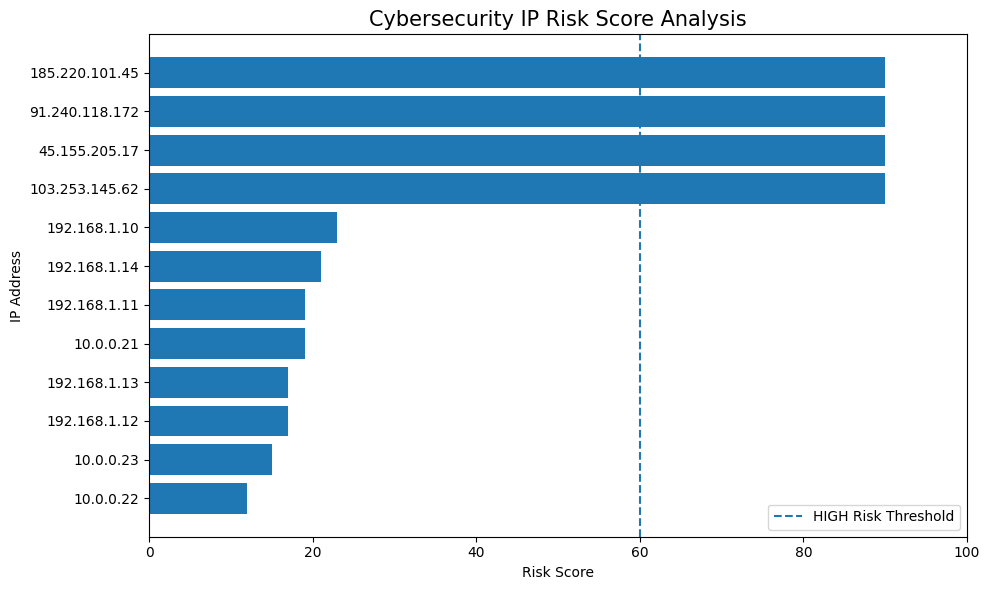

In [11]:
# IP Risk Score Visualization

risk_plot = ip_risk.sort_values(
    "risk_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    risk_plot["ip_address"],
    risk_plot["risk_score"]
)

# HIGH risk threshold
plt.axvline(
    x=60,
    linestyle="--",
    label="HIGH Risk Threshold"
)

plt.title(
    "Cybersecurity IP Risk Score Analysis",
    fontsize=15
)

plt.xlabel("Risk Score")
plt.ylabel("IP Address")

plt.xlim(0, 100)

plt.legend()

plt.tight_layout()

# Daha sonra LinkedIn / GitHub için kullanacağız
plt.savefig(
    "ip_risk_score.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [12]:
# ==========================================
# FEATURE ENGINEERING FOR MACHINE LEARNING
# ==========================================

# Her IP için toplam login sayısı
total_attempts = (
    df.groupby("ip_address")
    .size()
    .reset_index(name="total_attempts")
)

# Her IP için başarısız login sayısı
failed_attempts = (
    df[df["login_status"] == "Failed"]
    .groupby("ip_address")
    .size()
    .reset_index(name="failed_attempts")
)

# Her IP'nin kaç farklı kullanıcı hesabına eriştiği
unique_users = (
    df.groupby("ip_address")["username"]
    .nunique()
    .reset_index(name="unique_users")
)

# Daha önce oluşturduğumuz değerleri birleştir
ml_features = total_attempts.merge(
    failed_attempts,
    on="ip_address",
    how="left"
)

ml_features = ml_features.merge(
    unique_users,
    on="ip_address",
    how="left"
)

ml_features = ml_features.merge(
    max_failed_15min,
    on="ip_address",
    how="left"
)

ml_features = ml_features.merge(
    after_hours_analysis,
    on="ip_address",
    how="left"
)

# Boş değer varsa 0 yap
ml_features = ml_features.fillna(0)

# Failed login oranı
ml_features["failure_rate"] = (
    ml_features["failed_attempts"] /
    ml_features["total_attempts"]
)

print("=== MACHINE LEARNING FEATURE DATASET ===")

ml_features

=== MACHINE LEARNING FEATURE DATASET ===


,ip_address,total_attempts,failed_attempts,unique_users,max_failed_15min,after_hours_failed_attempts,failure_rate
0,10.0.0.21,627,57,10,1,17,0.090909
1,10.0.0.22,625,47,10,1,10,0.075200
2,10.0.0.23,604,62,10,2,11,0.102649
3,103.253.145.62,30,30,1,30,30,1.000000
4,185.220.101.45,30,30,1,30,30,1.000000
5,192.168.1.10,606,64,10,1,21,0.105611
6,192.168.1.11,640,53,10,2,15,0.082812
7,192.168.1.12,639,70,10,2,13,0.109546
8,192.168.1.13,652,61,10,1,15,0.093558
9,192.168.1.14,607,65,10,2,17,0.107084


In [13]:
# ==========================================
# MACHINE LEARNING - ISOLATION FOREST
# ==========================================

# Modelde kullanılacak davranış özellikleri
feature_columns = [
    "total_attempts",
    "failed_attempts",
    "unique_users",
    "max_failed_15min",
    "after_hours_failed_attempts",
    "failure_rate"
]

X = ml_features[feature_columns]

# Isolation Forest modeli
model = IsolationForest(
    n_estimators=200,
    contamination=0.33,
    random_state=42
)

# Modeli eğit
model.fit(X)

# Tahmin
ml_features["anomaly_prediction"] = model.predict(X)

# Anomaly score
ml_features["anomaly_score"] = model.decision_function(X)

# -1 = Anomaly, 1 = Normal
ml_features["ml_status"] = ml_features[
    "anomaly_prediction"
].map({
    1: "NORMAL",
    -1: "ANOMALY"
})

# Sonuçları anomaly score'a göre sırala
ml_results = ml_features.sort_values(
    "anomaly_score",
    ascending=True
).reset_index(drop=True)

print("=== ISOLATION FOREST ANOMALY DETECTION ===")

ml_results[
    [
        "ip_address",
        "total_attempts",
        "failed_attempts",
        "failure_rate",
        "max_failed_15min",
        "anomaly_score",
        "ml_status"
    ]
]

=== ISOLATION FOREST ANOMALY DETECTION ===


,ip_address,total_attempts,failed_attempts,failure_rate,max_failed_15min,anomaly_score,ml_status
0,103.253.145.62,30,30,1.000000,30,-0.019405,ANOMALY
1,185.220.101.45,30,30,1.000000,30,-0.019405,ANOMALY
2,45.155.205.17,30,30,1.000000,30,-0.019405,ANOMALY
3,91.240.118.172,30,30,1.000000,30,-0.019405,ANOMALY
4,10.0.0.22,625,47,0.075200,1,0.011396,NORMAL
5,192.168.1.10,606,64,0.105611,1,0.052500,NORMAL
6,192.168.1.12,639,70,0.109546,2,0.066899,NORMAL
7,10.0.0.23,604,62,0.102649,2,0.079442,NORMAL
8,192.168.1.11,640,53,0.082812,2,0.080063,NORMAL
9,192.168.1.13,652,61,0.093558,1,0.093653,NORMAL


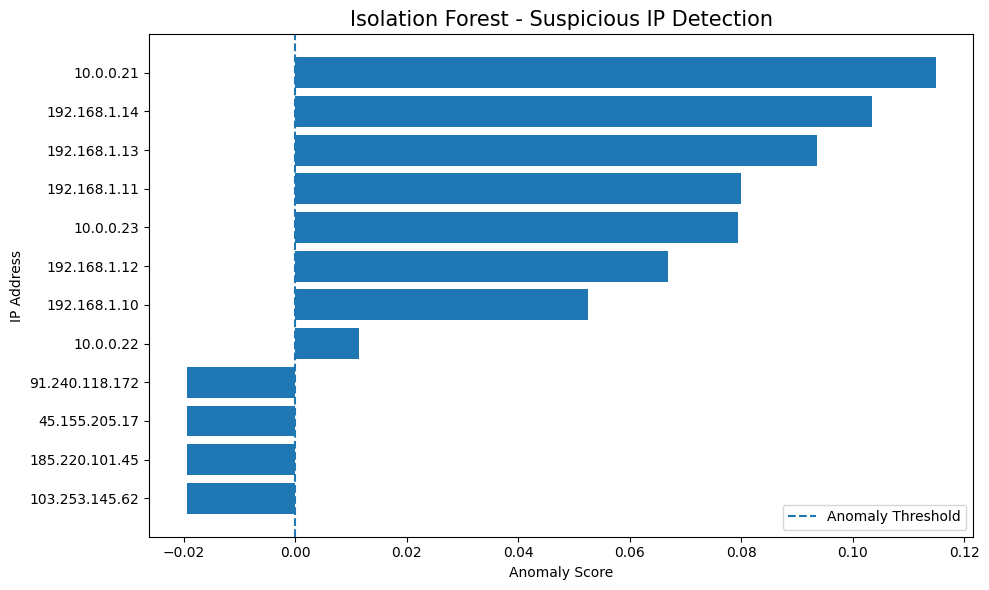

In [14]:
# ==========================================
# MACHINE LEARNING ANOMALY VISUALIZATION
# ==========================================

plot_data = ml_results.sort_values(
    "anomaly_score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["ip_address"],
    plot_data["anomaly_score"]
)

# Anomaly sınırı
plt.axvline(
    x=0,
    linestyle="--",
    label="Anomaly Threshold"
)

plt.title(
    "Isolation Forest - Suspicious IP Detection",
    fontsize=15
)

plt.xlabel("Anomaly Score")
plt.ylabel("IP Address")

plt.legend()

plt.tight_layout()

# GitHub / LinkedIn için görseli kaydet
plt.savefig(
    "ml_anomaly_detection.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ==========================================
# FINAL SECURITY ANALYSIS
# ==========================================

# Rule-based risk sonuçları ile ML sonuçlarını birleştir
final_analysis = ip_risk.merge(
    ml_results[
        [
            "ip_address",
            "total_attempts",
            "failed_attempts",
            "failure_rate",
            "unique_users",
            "anomaly_score",
            "ml_status"
        ]
    ],
    on="ip_address",
    how="left"
)

# Final security status
def final_status(row):
    if row["risk_level"] == "HIGH" and row["ml_status"] == "ANOMALY":
        return "CRITICAL - INVESTIGATE"
    elif row["risk_level"] == "HIGH" or row["ml_status"] == "ANOMALY":
        return "SUSPICIOUS"
    else:
        return "NORMAL"

final_analysis["final_status"] = final_analysis.apply(
    final_status,
    axis=1
)

# Kolonları düzenle
final_analysis = final_analysis[
    [
        "ip_address",
        "total_attempts",
        "failed_attempts",
        "failure_rate",
        "max_failed_15min",
        "after_hours_failed_attempts",
        "risk_score",
        "risk_level",
        "anomaly_score",
        "ml_status",
        "final_status"
    ]
]

final_analysis = final_analysis.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

print("=== FINAL SECURITY ANALYSIS ===")

final_analysis

=== FINAL SECURITY ANALYSIS ===


,ip_address,total_attempts,failed_attempts,failure_rate,max_failed_15min,after_hours_failed_attempts,risk_score,risk_level,anomaly_score,ml_status,final_status
0,103.253.145.62,30,30,1.000000,30,30,90,HIGH,-0.019405,ANOMALY,CRITICAL - INVESTIGATE
1,45.155.205.17,30,30,1.000000,30,30,90,HIGH,-0.019405,ANOMALY,CRITICAL - INVESTIGATE
2,91.240.118.172,30,30,1.000000,30,30,90,HIGH,-0.019405,ANOMALY,CRITICAL - INVESTIGATE
3,185.220.101.45,30,30,1.000000,30,30,90,HIGH,-0.019405,ANOMALY,CRITICAL - INVESTIGATE
4,192.168.1.10,606,64,0.105611,1,21,23,LOW,0.052500,NORMAL,NORMAL
5,192.168.1.14,607,65,0.107084,2,17,21,LOW,0.103447,NORMAL,NORMAL
6,10.0.0.21,627,57,0.090909,1,17,19,LOW,0.114930,NORMAL,NORMAL
7,192.168.1.11,640,53,0.082812,2,15,19,LOW,0.080063,NORMAL,NORMAL
8,192.168.1.12,639,70,0.109546,2,13,17,LOW,0.066899,NORMAL,NORMAL
9,192.168.1.13,652,61,0.093558,1,15,17,LOW,0.093653,NORMAL,NORMAL


In [18]:
# ==========================================
# PROFESSIONAL CYBERSECURITY EXCEL DASHBOARD
# ==========================================

!pip install XlsxWriter -q

import pandas as pd
import os

output_file = "Cybersecurity_Incident_Report_Professional.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="xlsxwriter",
    datetime_format="yyyy-mm-dd hh:mm:ss"
) as writer:

    workbook = writer.book

    # ==========================================
    # COLORS & FORMATS
    # ==========================================

    title_format = workbook.add_format({
        "bold": True,
        "font_size": 22,
        "font_color": "white",
        "bg_color": "#172554",
        "align": "center",
        "valign": "vcenter"
    })

    subtitle_format = workbook.add_format({
        "font_size": 10,
        "font_color": "#475569",
        "italic": True,
        "align": "center"
    })

    section_format = workbook.add_format({
        "bold": True,
        "font_size": 13,
        "font_color": "white",
        "bg_color": "#1E3A8A",
        "align": "left",
        "valign": "vcenter"
    })

    kpi_header = workbook.add_format({
        "bold": True,
        "font_color": "#475569",
        "bg_color": "#F1F5F9",
        "border": 1,
        "border_color": "#CBD5E1",
        "align": "center",
        "valign": "vcenter"
    })

    kpi_normal = workbook.add_format({
        "bold": True,
        "font_size": 20,
        "font_color": "#0F172A",
        "bg_color": "#FFFFFF",
        "border": 1,
        "border_color": "#CBD5E1",
        "align": "center",
        "valign": "vcenter"
    })

    kpi_warning = workbook.add_format({
        "bold": True,
        "font_size": 20,
        "font_color": "#92400E",
        "bg_color": "#FEF3C7",
        "border": 1,
        "border_color": "#F59E0B",
        "align": "center",
        "valign": "vcenter"
    })

    kpi_critical = workbook.add_format({
        "bold": True,
        "font_size": 20,
        "font_color": "#991B1B",
        "bg_color": "#FEE2E2",
        "border": 1,
        "border_color": "#EF4444",
        "align": "center",
        "valign": "vcenter"
    })

    info_header = workbook.add_format({
        "bold": True,
        "font_color": "white",
        "bg_color": "#334155",
        "border": 1,
        "align": "left"
    })

    info_text = workbook.add_format({
        "bg_color": "#F8FAFC",
        "border": 1,
        "text_wrap": True,
        "valign": "top"
    })


    # ==========================================
    # KPI CALCULATIONS
    # ==========================================

    total_events = len(df)

    total_failed = len(
        df[df["login_status"] == "Failed"]
    )

    brute_force_count = len(brute_force_alerts)

    anomaly_count = len(
        ml_results[
            ml_results["ml_status"] == "ANOMALY"
        ]
    )

    critical_count = len(
        final_analysis[
            final_analysis["final_status"]
            == "CRITICAL - INVESTIGATE"
        ]
    )


    # ==========================================
    # 1 - DASHBOARD
    # ==========================================

    dashboard = workbook.add_worksheet("Dashboard")
    writer.sheets["Dashboard"] = dashboard

    dashboard.hide_gridlines(2)

    dashboard.set_column("A:A", 2)
    dashboard.set_column("B:C", 16)
    dashboard.set_column("D:D", 3)
    dashboard.set_column("E:F", 16)
    dashboard.set_column("G:G", 3)
    dashboard.set_column("H:I", 16)
    dashboard.set_column("J:J", 3)
    dashboard.set_column("K:L", 16)

    dashboard.set_row(0, 32)
    dashboard.set_row(1, 32)

    # TITLE
    dashboard.merge_range(
        "B1:L2",
        "Cybersecurity Log Analysis & Threat Detection",
        title_format
    )

    dashboard.merge_range(
        "B3:L3",
        "Rule-Based Detection • Risk Scoring • Isolation Forest Machine Learning",
        subtitle_format
    )

    # KPI SECTION
    dashboard.merge_range(
        "B5:L5",
        "SECURITY OVERVIEW",
        section_format
    )

    # KPI 1
    dashboard.merge_range(
        "B7:C7",
        "TOTAL LOG EVENTS",
        kpi_header
    )

    dashboard.merge_range(
        "B8:C9",
        total_events,
        kpi_normal
    )

    # KPI 2
    dashboard.merge_range(
        "E7:F7",
        "FAILED LOGINS",
        kpi_header
    )

    dashboard.merge_range(
        "E8:F9",
        total_failed,
        kpi_warning
    )

    # KPI 3
    dashboard.merge_range(
        "H7:I7",
        "BRUTE FORCE ALERTS",
        kpi_header
    )

    dashboard.merge_range(
        "H8:I9",
        brute_force_count,
        kpi_critical
    )

    # KPI 4
    dashboard.merge_range(
        "K7:L7",
        "ML ANOMALIES",
        kpi_header
    )

    dashboard.merge_range(
        "K8:L9",
        anomaly_count,
        kpi_critical
    )

    # Critical IP
    dashboard.merge_range(
        "B11:C11",
        "CRITICAL IP ADDRESSES",
        kpi_header
    )

    dashboard.merge_range(
        "B12:C13",
        critical_count,
        kpi_critical
    )

    # Detection Method
    dashboard.merge_range(
        "E11:H11",
        "DETECTION METHOD",
        kpi_header
    )

    dashboard.merge_range(
        "E12:H13",
        "Rule-Based + Isolation Forest",
        kpi_normal
    )

    # Dataset
    dashboard.merge_range(
        "J11:L11",
        "DATASET",
        kpi_header
    )

    dashboard.merge_range(
        "J12:L13",
        "Synthetic Security Logs",
        kpi_normal
    )

    # ==========================================
    # CHART SECTION
    # ==========================================

    dashboard.merge_range(
        "B15:L15",
        "THREAT DETECTION VISUALIZATIONS",
        section_format
    )

    # Daha önce oluşturduğumuz grafik varsa Excel'e ekle
    if os.path.exists("ip_risk_score.png"):
        dashboard.insert_image(
            "B17",
            "ip_risk_score.png",
            {
                "x_scale": 0.55,
                "y_scale": 0.55
            }
        )

    if os.path.exists("ml_anomaly_detection.png"):
        dashboard.insert_image(
            "G17",
            "ml_anomaly_detection.png",
            {
                "x_scale": 0.55,
                "y_scale": 0.55
            }
        )

    # ==========================================
    # PROJECT INFORMATION
    # ==========================================

    dashboard.merge_range(
        "B39:L39",
        "PROJECT INFORMATION",
        section_format
    )

    dashboard.merge_range(
        "B41:C41",
        "Project Goal",
        info_header
    )

    dashboard.merge_range(
        "D41:L41",
        "Identify potentially malicious authentication activity "
        "using rule-based security analytics and machine learning.",
        info_text
    )

    dashboard.merge_range(
        "B43:C43",
        "Detected Threat",
        info_header
    )

    dashboard.merge_range(
        "D43:L43",
        "Brute-force authentication attempts and anomalous IP behaviour.",
        info_text
    )

    dashboard.merge_range(
        "B45:C45",
        "Machine Learning",
        info_header
    )

    dashboard.merge_range(
        "D45:L45",
        "Isolation Forest anomaly detection using authentication "
        "behaviour features.",
        info_text
    )

    dashboard.merge_range(
        "B47:C47",
        "Data Source",
        info_header
    )

    dashboard.merge_range(
        "D47:L47",
        "Synthetic authentication/security log dataset created "
        "for educational cybersecurity analysis.",
        info_text
    )


    # ==========================================
    # 2 - FINAL ANALYSIS
    # ==========================================

    final_analysis.to_excel(
        writer,
        sheet_name="Final Analysis",
        index=False
    )

    final_sheet = writer.sheets["Final Analysis"]

    final_sheet.freeze_panes(1, 0)
    final_sheet.autofilter(
        0,
        0,
        len(final_analysis),
        len(final_analysis.columns) - 1
    )

    final_sheet.set_column("A:A", 20)
    final_sheet.set_column("B:F", 20)
    final_sheet.set_column("G:G", 15)
    final_sheet.set_column("H:H", 15)
    final_sheet.set_column("I:I", 18)
    final_sheet.set_column("J:J", 15)
    final_sheet.set_column("K:K", 25)

    final_sheet.conditional_format(
        "K2:K100",
        {
            "type": "text",
            "criteria": "containing",
            "value": "CRITICAL",
            "format": workbook.add_format({
                "bg_color": "#FECACA",
                "font_color": "#991B1B",
                "bold": True
            })
        }
    )


    # ==========================================
    # 3 - SECURITY ALERTS
    # ==========================================

    security_alerts.to_excel(
        writer,
        sheet_name="Security Alerts",
        index=False
    )

    alerts_sheet = writer.sheets["Security Alerts"]

    alerts_sheet.freeze_panes(1, 0)

    alerts_sheet.set_column("A:A", 22)
    alerts_sheet.set_column("B:B", 20)
    alerts_sheet.set_column("C:C", 18)
    alerts_sheet.set_column("D:D", 15)
    alerts_sheet.set_column("E:E", 32)
    alerts_sheet.set_column("F:F", 55)


    # ==========================================
    # 4 - IP RISK ANALYSIS
    # ==========================================

    ip_risk.to_excel(
        writer,
        sheet_name="IP Risk Analysis",
        index=False
    )

    risk_sheet = writer.sheets["IP Risk Analysis"]

    risk_sheet.freeze_panes(1, 0)

    risk_sheet.set_column("A:A", 20)
    risk_sheet.set_column("B:C", 26)
    risk_sheet.set_column("D:D", 15)
    risk_sheet.set_column("E:E", 15)

    risk_sheet.conditional_format(
        "D2:D100",
        {
            "type": "data_bar",
            "bar_color": "#2563EB"
        }
    )

    risk_sheet.conditional_format(
        "E2:E100",
        {
            "type": "text",
            "criteria": "containing",
            "value": "HIGH",
            "format": workbook.add_format({
                "bg_color": "#FECACA",
                "font_color": "#991B1B",
                "bold": True
            })
        }
    )


    # ==========================================
    # 5 - MACHINE LEARNING RESULTS
    # ==========================================

    ml_results.to_excel(
        writer,
        sheet_name="ML Results",
        index=False
    )

    ml_sheet = writer.sheets["ML Results"]

    ml_sheet.freeze_panes(1, 0)

    ml_sheet.set_column("A:A", 20)
    ml_sheet.set_column("B:I", 22)

    ml_sheet.conditional_format(
        "I2:I100",
        {
            "type": "text",
            "criteria": "containing",
            "value": "ANOMALY",
            "format": workbook.add_format({
                "bg_color": "#FECACA",
                "font_color": "#991B1B",
                "bold": True
            })
        }
    )


    # ==========================================
    # 6 - RAW LOGS
    # ==========================================

    df.to_excel(
        writer,
        sheet_name="Raw Logs",
        index=False
    )

    raw_sheet = writer.sheets["Raw Logs"]

    raw_sheet.freeze_panes(1, 0)

    raw_sheet.autofilter(
        0,
        0,
        len(df),
        len(df.columns) - 1
    )

    raw_sheet.set_column("A:A", 22)
    raw_sheet.set_column("B:B", 15)
    raw_sheet.set_column("C:C", 20)
    raw_sheet.set_column("D:D", 20)
    raw_sheet.set_column("E:E", 15)
    raw_sheet.set_column("F:F", 15)
    raw_sheet.set_column("G:G", 12)


print("Professional Excel dashboard successfully created!")
print("File:", output_file)

Professional Excel dashboard successfully created!
File: Cybersecurity_Incident_Report_Professional.xlsx
